# Shabaka Pulse — Facility Clustering and Dispatch Allocation

This notebook performs unsupervised operational tiering of 30 industrial facilities using K-Means clustering and implements a priority-based demand-response dispatch algorithm.

The analysis:
1. Scales flexibility metrics (`max_flex_mw` and `ramp_rate_mw_per_min`).
2. Validates optimal cluster selection (k = 3).
3. Maps unlabelled K-Means clusters to operational demand-response Tiers (Tier 1 = Hydraulic, Tier 2 = Thermal, Tier 3 = Batch).
4. Cross-validates clusters against ground-truth industry classifications.
5. Implements a priority dispatch solver for allocating renewable surplus power.

## 1. Setup

Importing data handling, scaling, machine learning, and plotting libraries. We load `data/facilities.csv` into a pandas DataFrame.

In [1]:
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load facility dataset
data_path = Path("data/facilities.csv")
df_facilities = pd.read_csv(data_path)

display(df_facilities.head())
print(f"Loaded dataset shape: {df_facilities.shape[0]} rows, {df_facilities.shape[1]} columns")

,facility_id,facility_name,industry_type,max_flex_mw,ramp_rate_mw_per_min,storage_type,lat,lon
0,FAC-001,Desalination Plant #1,Desalination Plant,20.97,3.65,hydraulic,30.9270,29.4824
1,FAC-002,Food Preservation Facility #1,Food Preservation Facility,16.42,1.29,thermal,30.8792,29.5373
2,FAC-003,Steel Rolling Mill #1,Steel Rolling Mill,95.61,0.36,batch,29.9064,32.5734
3,FAC-004,Desalination Plant #2,Desalination Plant,23.86,1.66,hydraulic,24.4739,32.7375
4,FAC-005,Cold Storage Logistics #1,Cold Storage Logistics,10.32,1.47,thermal,30.8723,29.5586


Loaded dataset shape: 30 rows, 8 columns


## 2. Feature scaling

K-Means relies on Euclidean distance metrics. Because flexible capacity (`max_flex_mw`, 5–100 MW) and ramp rates (`ramp_rate_mw_per_min`, 0.1–4.0 MW/min) exist on significantly different numeric scales, unscaled clustering would cause `max_flex_mw` to dominate distance calculations.

We apply `StandardScaler` to standardize both features to zero mean and unit variance.

In [2]:
feature_cols = ["max_flex_mw", "ramp_rate_mw_per_min"]
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df_facilities[feature_cols])

# Diagnostic inspection of scaled feature distribution
scaled_summary = pd.DataFrame(
    scaled_features, columns=["scaled_max_flex_mw", "scaled_ramp_rate"]
).describe()

display(scaled_summary.round(3))

,scaled_max_flex_mw,scaled_ramp_rate
count,30.000,30.000
mean,-0.000,-0.000
std,1.017,1.017
min,-1.073,-1.185
25%,-0.829,-0.920
50%,-0.497,-0.163
75%,0.934,0.772
max,1.872,2.371


## 3. Determine and validate cluster count

We compute the K-Means inertia (within-cluster sum of squares) across k = 1 to k = 6 to evaluate cluster compactness and plot the elbow curve.

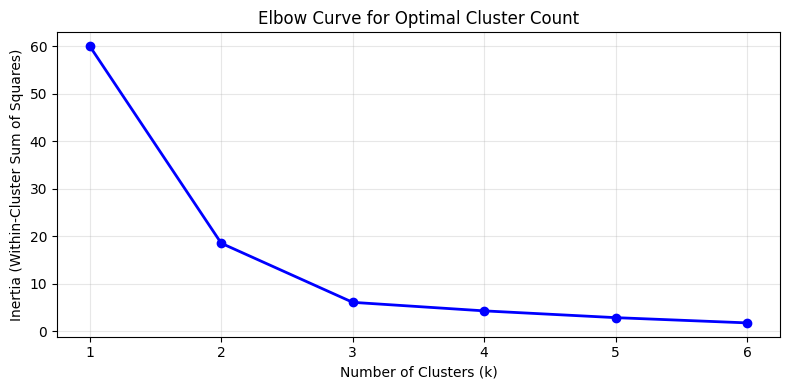

In [3]:
inertia_values = []
k_range = range(1, 7)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_test.fit(scaled_features)
    inertia_values.append(kmeans_test.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertia_values, "bo-", linewidth=2, markersize=6)
ax.set_title("Elbow Curve for Optimal Cluster Count")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax.set_xticks(k_range)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The elbow curve shows a sharp reduction in inertia at k = 3, indicating that three clusters capture the underlying feature variance effectively.

Furthermore, k = 3 directly corresponds to the three physical demand-response storage mechanisms (Hydraulic, Thermal, and Batch processing). We fix k = 3 for subsequent operational tiering.

## 4. Run K-Means clustering

Executing K-Means clustering with k = 3 on the standardized flexibility features and storing the raw cluster assignments.

In [4]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df_facilities["raw_cluster"] = kmeans.fit_predict(scaled_features)

display(df_facilities[["facility_id", "facility_name", "max_flex_mw", "ramp_rate_mw_per_min", "raw_cluster"]].head())

,facility_id,facility_name,max_flex_mw,ramp_rate_mw_per_min,raw_cluster
0,FAC-001,Desalination Plant #1,20.97,3.65,1
1,FAC-002,Food Preservation Facility #1,16.42,1.29,2
2,FAC-003,Steel Rolling Mill #1,95.61,0.36,0
3,FAC-004,Desalination Plant #2,23.86,1.66,2
4,FAC-005,Cold Storage Logistics #1,10.32,1.47,2


## 5. Map raw clusters to meaningful tier numbers

K-Means cluster IDs (0, 1, 2) are arbitrary integer labels. To align with domain physics, we map raw clusters to operational Tiers (1, 2, 3) by ranking each cluster's mean `ramp_rate_mw_per_min` in descending order:
- **Tier 1**: Fastest average ramp rate (Hydraulic storage buffer).
- **Tier 2**: Moderate average ramp rate (Thermal storage buffer).
- **Tier 3**: Lowest average ramp rate (Batch processing silos).

We retain `raw_cluster` alongside the assigned `tier` column for reference and auditing.

In [5]:
# Calculate average ramp rate per raw cluster to establish physical ordering
cluster_ramp_means = (
    df_facilities.groupby("raw_cluster")["ramp_rate_mw_per_min"]
    .mean()
    .sort_values(ascending=False)
)

# Map highest ramp rate to Tier 1, second to Tier 2, lowest to Tier 3
tier_mapping = {
    raw_cluster_id: tier_num
    for tier_num, raw_cluster_id in enumerate(cluster_ramp_means.index, start=1)
}

df_facilities["tier"] = df_facilities["raw_cluster"].map(tier_mapping)

display(df_facilities.groupby("tier")[feature_cols].mean().round(2))

,max_flex_mw,ramp_rate_mw_per_min
tier,,
1,24.57,2.72
2,12.85,1.17
3,79.18,0.32


## 6. Validate the clustering against known industry_type labels

We evaluate alignment between unsupervised `tier` assignments and ground-truth `storage_type` classifications using a cross-tabulation table (`pd.crosstab`). Because `storage_type` was withheld from the clustering algorithm, agreement confirms the unsupervised model recovered the physical storage tiers.

In [6]:
crosstab_validation = pd.crosstab(
    df_facilities["tier"],
    df_facilities["storage_type"],
    margins=True,
    margins_name="Total",
)

display(crosstab_validation)

storage_type,batch,hydraulic,thermal,Total
tier,,,,
1,0,8,0,8
2,0,2,10,12
3,10,0,0,10
Total,10,10,10,30


## 7. Visualize the clusters

Plotting facilities in flexibility feature space (`max_flex_mw` vs `ramp_rate_mw_per_min`), color-coded by assigned `tier`.

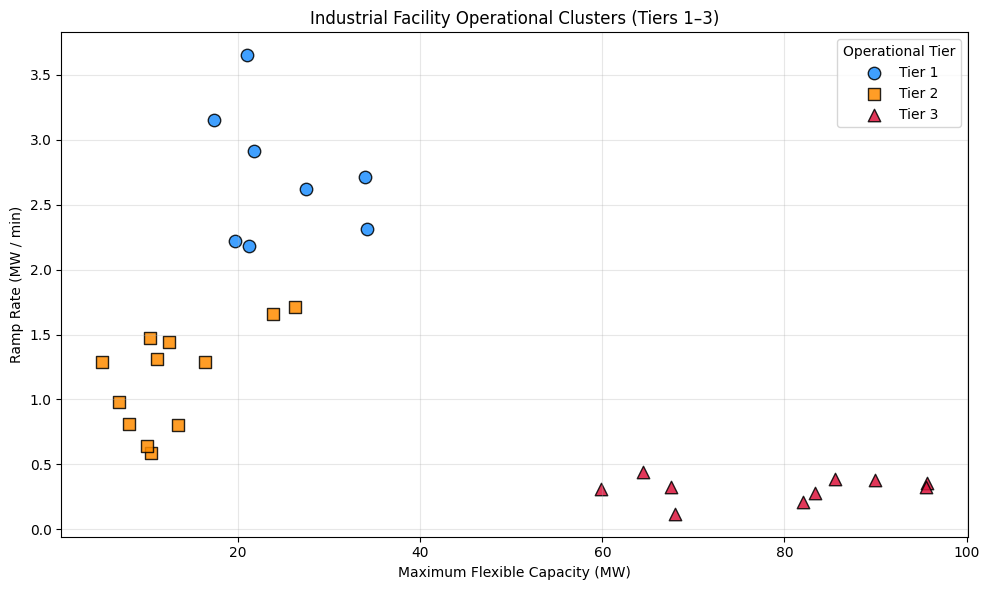

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {1: "dodgerblue", 2: "darkorange", 3: "crimson"}
markers = {1: "o", 2: "s", 3: "^"}

for tier_num in sorted(df_facilities["tier"].unique()):
    subset = df_facilities[df_facilities["tier"] == tier_num]
    ax.scatter(
        subset["max_flex_mw"],
        subset["ramp_rate_mw_per_min"],
        c=colors[tier_num],
        marker=markers[tier_num],
        s=80,
        alpha=0.85,
        edgecolors="k",
        label=f"Tier {tier_num}",
    )

ax.set_title("Industrial Facility Operational Clusters (Tiers 1–3)")
ax.set_xlabel("Maximum Flexible Capacity (MW)")
ax.set_ylabel("Ramp Rate (MW / min)")
ax.legend(title="Operational Tier")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Implement the priority dispatch solver

The priority dispatch solver allocates renewable energy surplus (MW) across industrial facilities in strict operational order:
1. **Tier 1 (Hydraulic)**: Allocated first due to fast response times and zero product disruption.
2. **Tier 2 (Thermal)**: Allocated second within thermal tolerance windows.
3. **Tier 3 (Batch)**: Allocated last to avoid interrupting active material batch cycles.

Within each tier, surplus power is distributed facility-by-facility up to each plant's `max_flex_mw` until the surplus is fully absorbed or system capacity is exhausted.

In [8]:
def allocate_surplus(
    surplus_mw: float,
    clustered_facilities: pd.DataFrame,
) -> Tuple[Dict[str, float], float]:
    """Allocates available renewable surplus power across facilities by tier priority.

    Parameters
    ----------
    surplus_mw : float
        Total surplus power available for demand response (MW).
    clustered_facilities : pd.DataFrame
        DataFrame containing facility properties with a 'tier' column.

    Returns
    -------
    Tuple[Dict[str, float], float]
        Dictionary mapping facility_id to allocated_mw, and remaining unallocated surplus (MW).
    """
    remaining_surplus = float(surplus_mw)
    allocations: Dict[str, float] = {}

    # Sort facilities by tier priority (Tier 1 first, then 2, then 3), then by facility_id
    sorted_facilities = clustered_facilities.sort_values(
        by=["tier", "facility_id"]
    )

    for _, row in sorted_facilities.iterrows():
        fac_id = str(row["facility_id"])
        cap_mw = float(row["max_flex_mw"])

        if remaining_surplus <= 0.0:
            allocations[fac_id] = 0.0
        else:
            allocated = min(cap_mw, remaining_surplus)
            allocations[fac_id] = round(allocated, 4)
            remaining_surplus -= allocated

    return allocations, round(remaining_surplus, 4)

## 9. Test the dispatch solver with realistic surplus values

Testing the dispatch solver across three operational surplus scenarios:
- **Low Surplus (15 MW)**: Partially absorbed by Tier 1 facilities.
- **Medium Surplus (200 MW)**: Fully absorbs Tier 1 capacity and spills into Tier 2.
- **High Surplus (1500 MW)**: Exceeds total system flexible capacity, leaving unallocated surplus.

For each scenario, we verify that Allocated MW + Remaining MW = Input Surplus MW.

In [9]:
test_surplus_levels = [15.0, 200.0, 1500.0]
test_results = []

total_system_flex_mw = df_facilities["max_flex_mw"].sum()

for surplus in test_surplus_levels:
    allocations, remaining = allocate_surplus(surplus, df_facilities)
    
    allocated_total = sum(allocations.values())
    active_facilities_count = sum(1 for mw in allocations.values() if mw > 0.0)
    
    # Assert conservation of energy
    assert abs((allocated_total + remaining) - surplus) < 1e-3, (
        f"Energy balance mismatch for surplus {surplus}: "
        f"allocated ({allocated_total}) + remaining ({remaining}) != {surplus}"
    )

    test_results.append(
        {
            "input_surplus_mw": surplus,
            "allocated_facilities_count": active_facilities_count,
            "total_allocated_mw": round(allocated_total, 2),
            "remaining_unallocated_mw": round(remaining, 2),
            "system_capacity_mw": round(total_system_flex_mw, 2),
        }
    )

display(pd.DataFrame(test_results))

,input_surplus_mw,allocated_facilities_count,total_allocated_mw,remaining_unallocated_mw,system_capacity_mw
0,15.0,1,15.00,0.00,1142.59
1,200.0,9,200.00,0.00,1142.59
2,1500.0,30,1142.59,357.41,1142.59


## 10. Save the clustered dataset

Saving the processed facilities DataFrame (with assigned `tier` and `raw_cluster` columns) to `data/facilities_clustered.csv`.

In [10]:
output_path = Path("data/facilities_clustered.csv")
df_facilities.to_csv(output_path, index=False)

tier_distribution = df_facilities["tier"].value_counts().sort_index().to_frame()
tier_distribution.columns = ["facility_count"]

display(tier_distribution)
print(f"Saved clustered facilities dataset to {output_path.resolve()}")

,facility_count
tier,
1,8
2,12
3,10


Saved clustered facilities dataset to D:\shabaka-pluse\data\facilities_clustered.csv


## Next step

This clustered dataset (`data/facilities_clustered.csv`) and the priority `allocate_surplus` dispatch function are ready for integration into the settlement engine and Streamlit interactive dashboard.